# Isoprene Sensitivity Studies

---
Last modified: February 6th, 2025 (JY)

This notebook uses a modified version of vSmartMOM with functions specifically for isoprene to calculate radiances with different amounts of isoprene/water vapor/aerosols/etc.

This notebook is coded in Julia.

In [1]:
# Activate Julia packages
using Pkg;
using Revise;

Pkg.activate("vSmartMOM_ISOP.jl");
Pkg.instantiate();

# Using local module, since the current version of vSmartMOM does not support isoprene (not a HITRAN line list species)
include("vSmartMOM_ISOP.jl/src/vSmartMOM.jl");

# Other imports
using Statistics, PlutoUI, Polynomials, PlotlyBase, Plots, LazyArtifacts, LinearAlgebra, NCDatasets, Format, LaTeXStrings, .vSmartMOM;
include("helper_functions.jl");

default(fontfamily="Helvetica");

  Activating project at `~/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl`


### We now need to specify parameters for the model.

I have downloaded 10 days (2019-07-01 to 2019-07-10) in the MERRA2 folder. You will need to manually download more days if you would like different conditions.

In [2]:
function retrieve_merra2_conditions(date, startTime, lat, lon)
    # Feel free to change the MERRA2 file and folder paths
    MerraFile = "MERRA2_400.inst6_3d_ana_Nv." * date * ".nc4"
    MerraFolder = "MERRA2/"
    MerraFilePath = joinpath(MerraFolder, MerraFile)

    # These files have 00, 06, 12 or 18 in UTC, i.e. 6 hourly data stacked together
    hour = parse(Int, chop(startTime));
    hour_index = Int(hour / 6);

    # Read atmos profile (from helperfunctions.jl)
    return read_atmos_profile(MerraFilePath, lat, lon, hour_index);
end

# Parameters for atmospheric profile
date = "20190701"
startTime = "06z"
lat = 2.
lon = 100.

merra2_profile = retrieve_merra2_conditions(date, startTime, lat, lon);

pressures = merra2_profile.p_levels ./ 100; # Convert to hPa
pressures_midpoints = merra2_profile.p ./ 100; # Convert to hPa
temperatures = merra2_profile.T;
specific_humidity = merra2_profile.q .* 1000; # Convert from kg/kg (in MERRA2) to g/kg;

ds["T"] = T (576 × 361 × 72 × 4)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × lev × time
  Attributes:
   long_name            = Air temperature
   units                = K
   _FillValue           = 1.0e15
   missing_value        = 1.0e15
   fmissing_value       = 1.0e15
   scale_factor         = 1.0
   add_offset           = 0.0
   standard_name        = air_temperature
   vmax                 = 1.0e15
   vmin                 = -1.0e15
   valid_range          = Float32[-1.0f15, 1.0f15]



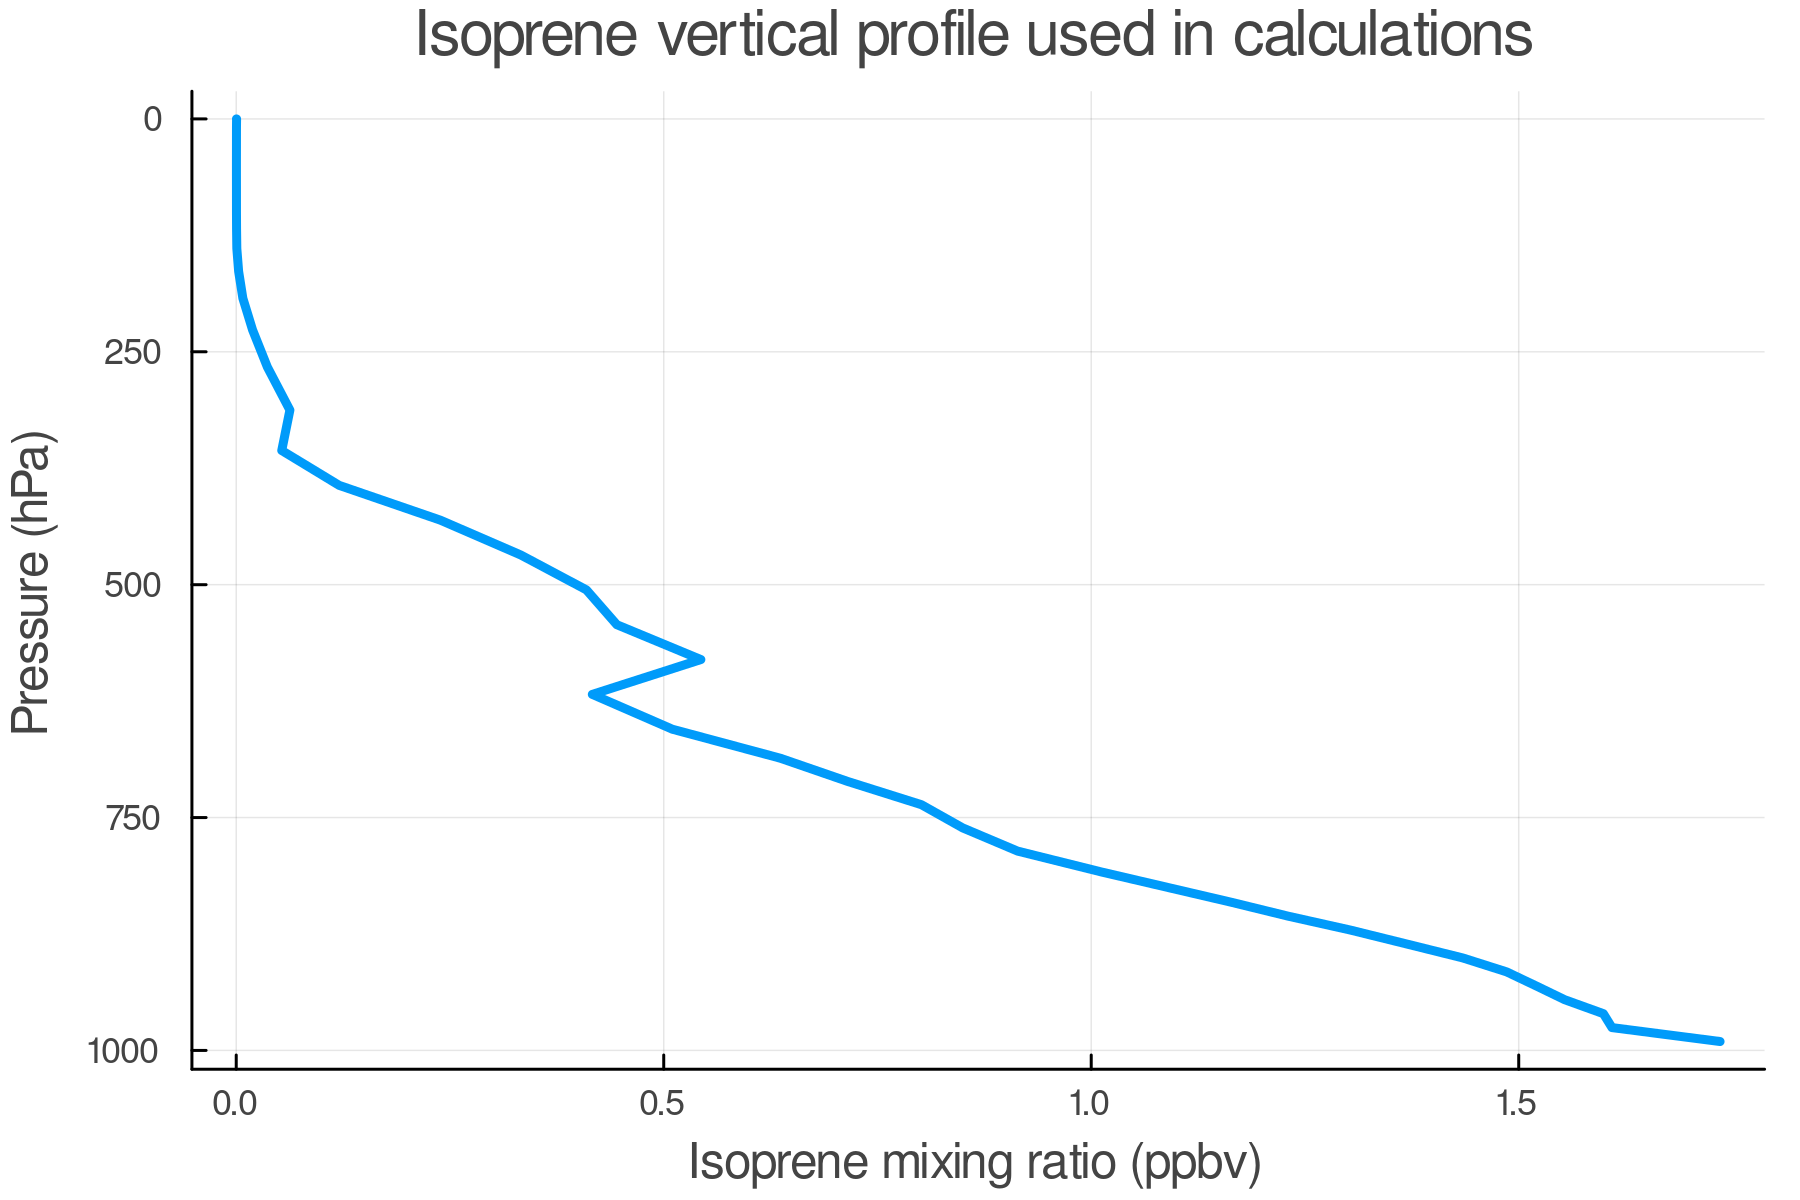

In [3]:
p = plot(specific_humidity ./ 1000 .* 1e-7 .* 1e9, pressures_midpoints, yflip = true, lw = 3, dpi = 300, label = "")
xlabel!("Isoprene mixing ratio (ppbv)")
ylabel!("Pressure (hPa)")
title!("Isoprene vertical profile used in calculations")
# savefig(p, "Figures/isoprene_vertical_profile.png")

In [10]:
current_profile = specific_humidity ./ 1000 .* 1e-7; # Get current isoprene vertical profile
total_column = merra2_profile.vcd_dry .* current_profile; # Multiply by vertical column density
total_column = sum(total_column) # Sum for the total column
println("The total column is $(total_column) molec cm-2")

mean_vmr = total_column / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr * 1e9) ppbv")

current_profile_x5 = specific_humidity ./ 1000 .* 1e-7 .* 5; # Get current isoprene vertical profile
total_column_x5 = merra2_profile.vcd_dry .* current_profile_x5; # Multiply by vertical column density
total_column_x5 = sum(total_column_x5) # Sum for the total column
println("The total column is $(total_column_x5) molec cm-2")

mean_vmr_x5 = total_column_x5 / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr_x5 * 1e9) ppbv")

The total column is 1.0351391432445896e16 molec cm-2
The equivalent constant VMR is 0.49235111030987266 ppbv
The total column is 5.175695716222948e16 molec cm-2
The equivalent constant VMR is 2.4617555515493637 ppbv


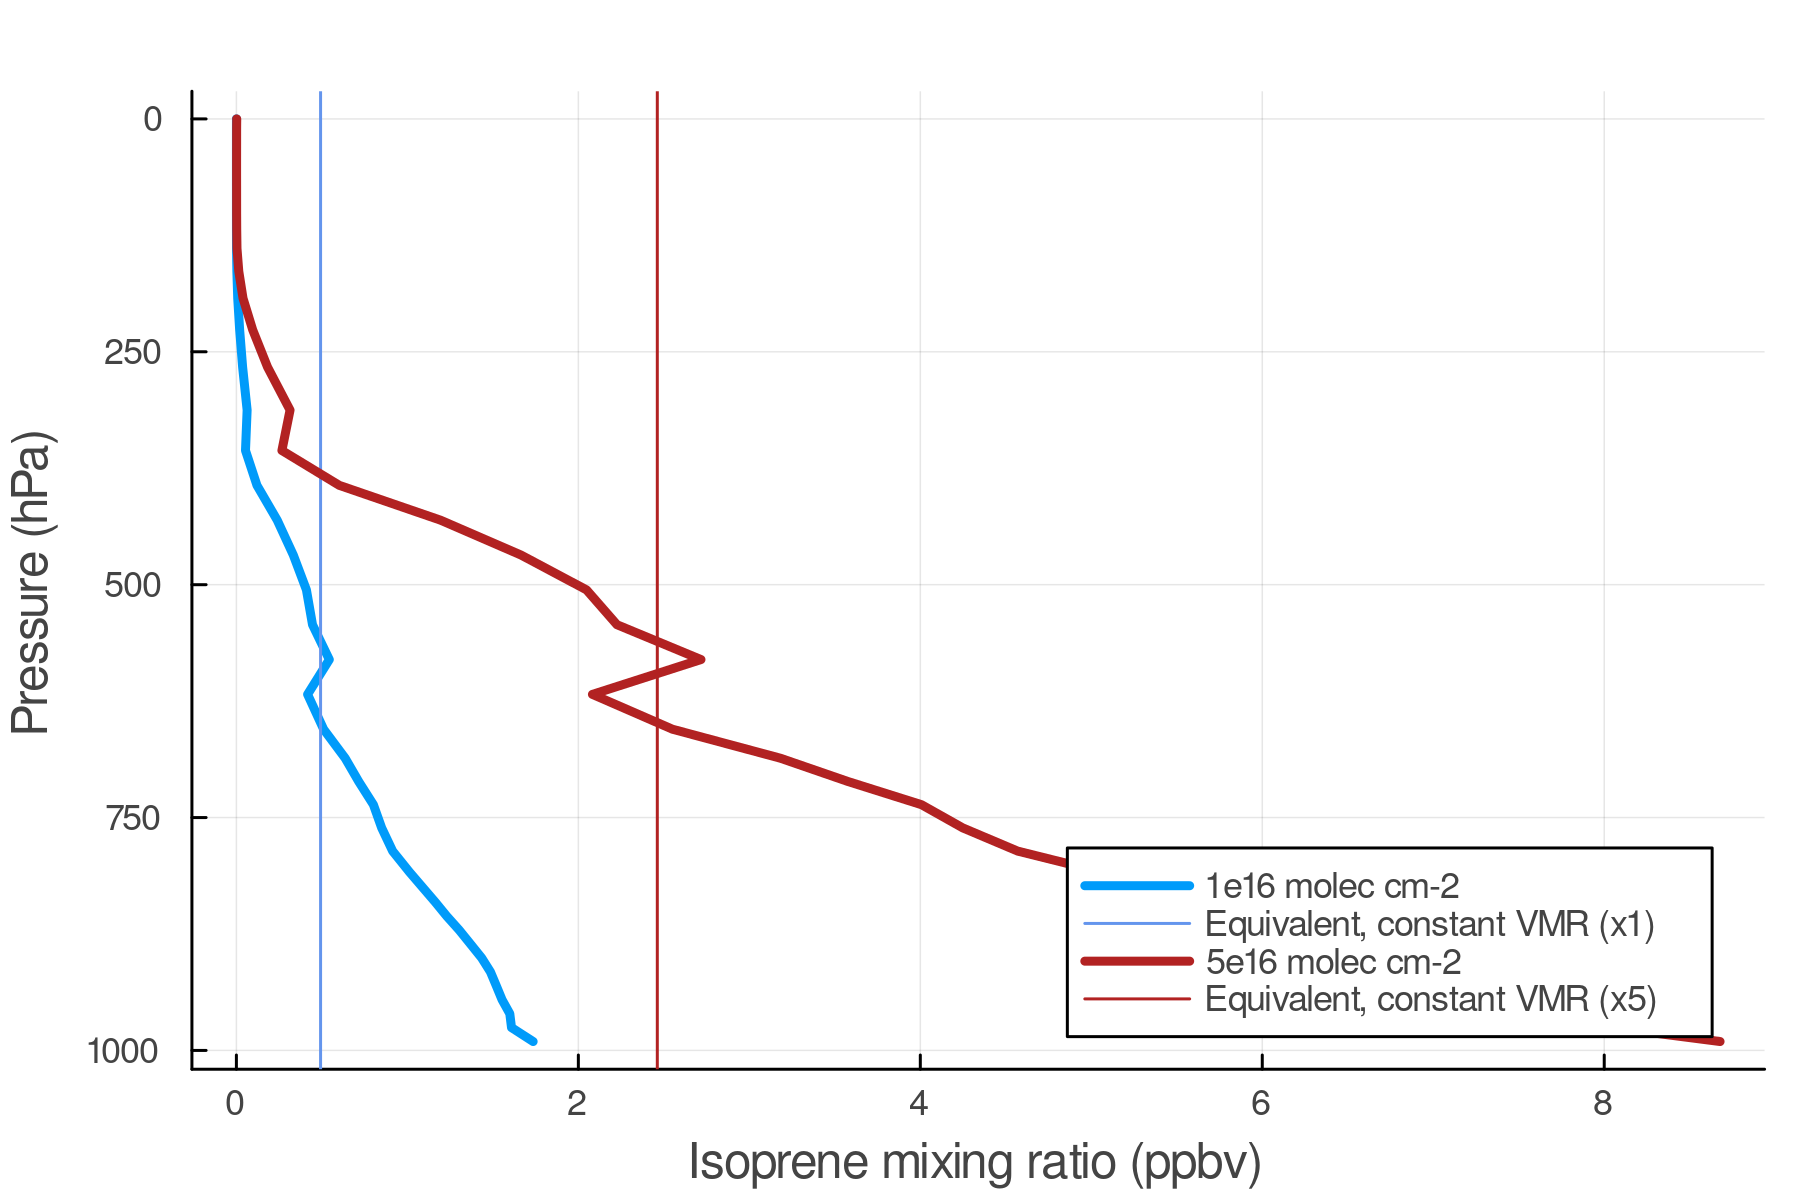

sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file
sh: latex: command not found
latex: failed to create a dvi file


In [12]:
p = plot(specific_humidity ./ 1000 .* 1e-7 .* 1e9, pressures_midpoints, yflip = true, lw = 3, dpi = 300, label = "1e16 molec cm-2")
vline!([mean_vmr * 1e9], label = "Equivalent, constant VMR (x1)", color = "cornflowerblue")

plot!(specific_humidity ./ 1000 .* 1e-7 .* 1e9 * 5, pressures_midpoints, yflip = true, lw = 3, dpi = 300, color = "firebrick", label = "5e16 molec cm-2")
vline!([mean_vmr_x5 * 1e9], label = "Equivalent, constant VMR (x5)", color = "firebrick")


xlabel!("Isoprene mixing ratio (ppbv)")
ylabel!("Pressure (hPa)")
title!(L"Isoprene vertical profile used in calculations")
# savefig(p, "Figures/isoprene_vertical_profile.png")

In [114]:
p = plot(specific_humidity ./ 1000 * 1e-7 * 1e9, pressures_midpoints, yflip = true, lw = 3, dpi = 600, label = "HNO3 (ppbv)", color = "cornflowerblue")
plot!(specific_humidity ./ 1000 * 1e-7 * 1e9 * 2, pressures_midpoints, yflip = true, lw = 3, dpi = 300, label = "HNO3 x 2 (ppbv)", color = "cornflowerblue", linestyle=:dash)
vline!([1], label = "1 ppbv", color = "firebrick")
xlabel!("HNO3 mixing ratio (ppbv)")
ylabel!("Pressure (hPa)")
title!("HNO3 vertical profile used in calculations")
savefig(p, "Figures/HNO3_profiles.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/Figures/HNO3_profiles.png"

## Create instrument kernel!

In [3]:
import InstrumentOperator: FTSInstrument, create_instrument_kernel, FixedKernelInstrument, conv_spectra

ν_min = 890.
ν_max = 910.
Δν = 0.01
ν = ν_min:Δν:ν_max

x = -5:Δν:5
fov = 16.8 #mrads
mopd = 0.8 #cm
FTS = FTSInstrument(0.8, fov * 1e-3, 0.)
unapodized_fts = create_instrument_kernel(FTS, x, 900.0)

p = plot(x, unapodized_fts.parent,label="CrIS Unapodized FTS Lineshape",lw=2, dpi = 300, title = "CrIS Unapodized FTS Instrument Line Shape \n(FOV = 16.8 mrads, MOPD = 0.8 cm)")
ylabel!("Channel Response Function")
xlabel!("σ (cm^-1)")
# savefig(p, "Figures/unapodized_instrument_kernel.png")

margin = 0
sampling = 0.625
cris_instrument_kernel = FixedKernelInstrument(unapodized_fts, collect(ν_min+margin:sampling:ν_max-margin))

┌ Info: Center of OffsetArrays is 
│   minimum(abs.(grid_x)) = 0.0
└ @ InstrumentOperator /Users/jamesyoon/.julia/packages/InstrumentOperator/JJWCH/src/prepare_ils.jl:39


(Θ, β) = (0.12700800000000004, 0.0)


FixedKernelInstrument{Float64}([-0.0001938027449118005, -0.00022515990131574464, -0.0002560745521885616, -0.0002864668905839412, -0.0003162580989748737, -0.0003453705508071965, -0.00037372800988458884, -0.00040125582708002165, -0.0004278811338732687, -0.00045353303222005073  …  -0.00011292824838757243, -9.056541516724512e-5, -7.058344327000462e-5, -5.30230478386403e-5, -3.791869420702852e-5, -2.529853680148194e-5, -1.5184374041206004e-5, -7.5916192866803565e-6, -2.5292878448332848e-6, -1.463672932855431e-18], [890.0, 890.625, 891.25, 891.875, 892.5, 893.125, 893.75, 894.375, 895.0, 895.625  …  904.375, 905.0, 905.625, 906.25, 906.875, 907.5, 908.125, 908.75, 909.375, 910.0])

### We can finally run the model!

In [4]:
# No absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/no_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
no_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
no_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, no_absorption[1][1,1,:]);

# Only CO2, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_absorption[1][1,1,:]);

# CO2, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = 0;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_H2O_absorption[1][1,1,:]);


FT_dual = Float64
Finished initializing arrays


┌ Info: Processing on: CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (11, 11, 2001)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/rt_run.jl:108


Fourier Moment: 0/2


Looping over layers ... 100%|████████████████████████████| Time: 0:00:05


Fourier Moment: 1/2


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               67.9s /  91.5%           64.3GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    57.5s   92.5%   14.4s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.37s    7.0%  20.2ms   9.66GiB   15.6%  45.8MiB
  interaction                   213    3.08s    5.0%  14.5ms   9.55GiB   15.5%  45.9MiB
    interaction inv2            213    865ms    1.4%  4.06ms   2.75GiB    4.5%  13.2MiB
    interaction inv1 bla        213    855ms    1.4%  4.01ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [5]:
# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption[1][1,1,:]);

# CO2, ISOP, H2O, O2 absorption but ISOP x 5
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_x5 = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_x5_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_x5[1][1,1,:]);


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr [2.8061060675099726e-13, 3.422330792091088e-13, 3.7959910059726096e-13, 4.1038783820113164e-13, 4.166083272139076e-13, 4.2227966332575304e-13, 4.2465917431400157e-13, 4.2646352085284886e-13, 4.2652359297790095e-13, 4.2673227653722277e-13, 4.2585279516060835e-13, 4.2171050154138353e-13, 4.1605308069847525e-13, 4.074657681485405e-13, 3.979811936005717e-13, 3.8654193303955254e-13, 3.769012437260244e-13, 3.6913961594109423e-13, 3.595829184632748e-13, 3.495272267173277e-13, 3.371887260072981e-13, 3.2509281027159884e-13, 3.100484718743246e-13, 2.9689333587157306e-13, 2.85915575659601e-13, 2.778988346108235e-13, 2.7219120966037733e-13, 2.700427785384818e-13, 2.6839841211767634e-13, 2.650610213095206e-13, 2.581584340077825e-13, 2.489701728336513e-13, 2.36811501963529

Progress: 100%|█████████████████████████████████████████| Time: 0:00:48


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               68.4s /  91.9%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    58.4s   92.9%   14.6s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.19s    6.7%  19.4ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    2.93s    4.7%  13.8ms   9.55GiB   15.5%  45.9MiB
    interaction inv1 bla        213    798ms    1.3%  3.74ms   2.75GiB    4.5%  13.2MiB
    interaction inv2            213    790ms    1.3%  3.71ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


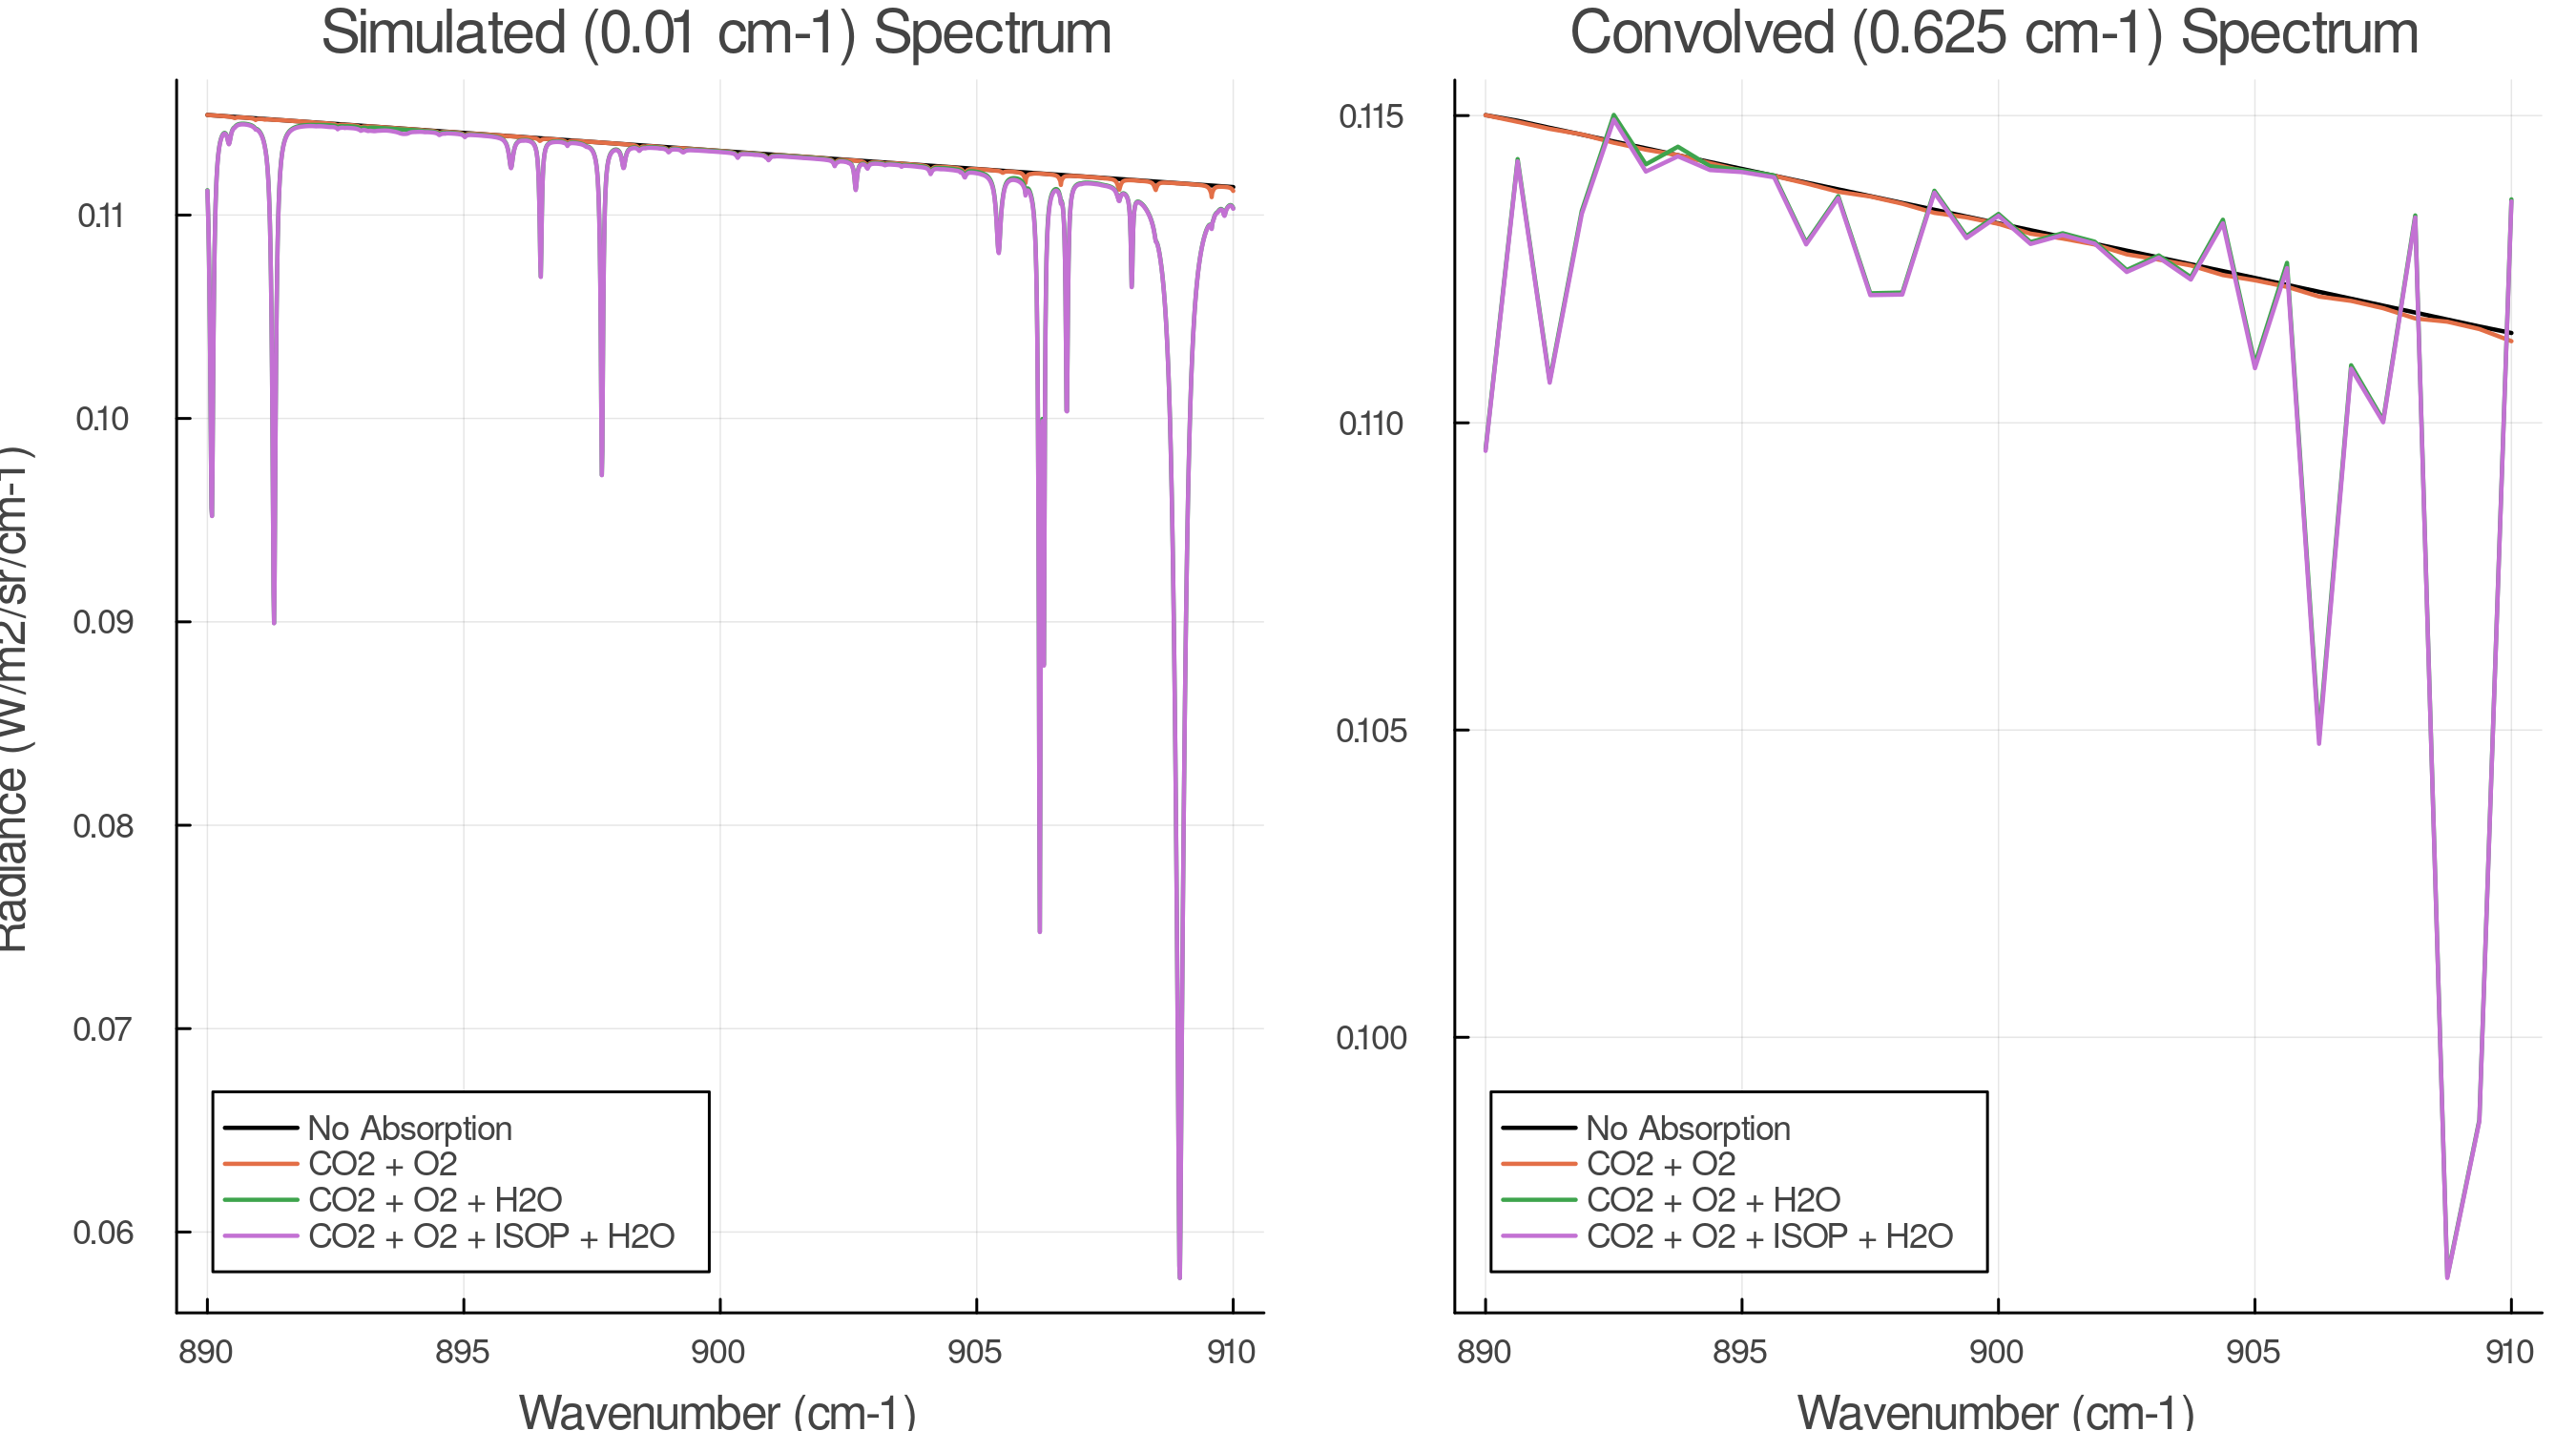

In [9]:

p1 = plot(cris_instrument_kernel.ν_out, no_absorption_kernel, label="No Absorption", color = "black", lw = 1.5, dpi = 300)
plot!(cris_instrument_kernel.ν_out, CO2_O2_absorption_kernel, label="CO2 + O2", lw = 1.5)
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label="CO2 + O2 + H2O", lw = 1.5)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel, label="CO2 + O2 + ISOP + H2O", lw = 1.5)
title!("Convolved (0.625 cm-1) Spectrum")
xlabel!("Wavenumber (cm-1)")

p2 = plot(ν, no_absorption[1][1,1,:], label="No Absorption", color = "black", lw = 1.5, dpi = 300)
plot!(ν, CO2_O2_absorption[1][1,1,:], label="CO2 + O2", lw = 1.5)
plot!(ν, CO2_O2_H2O_absorption[1][1,1,:], label="CO2 + O2 + H2O", lw = 1.5)
plot!(ν, CO2_O2_ISOP_H2O_absorption[1][1,1,:], label="CO2 + O2 + ISOP + H2O", lw = 1.5)
title!("Simulated (0.01 cm-1) Spectrum")
ylabel!("Radiance (W/m2/sr/cm-1)")
xlabel!("Wavenumber (cm-1)")

p3 = plot(p2, p1, size=(900,500))
# savefig(p3, "Figures/simulated_v_convolved.png")

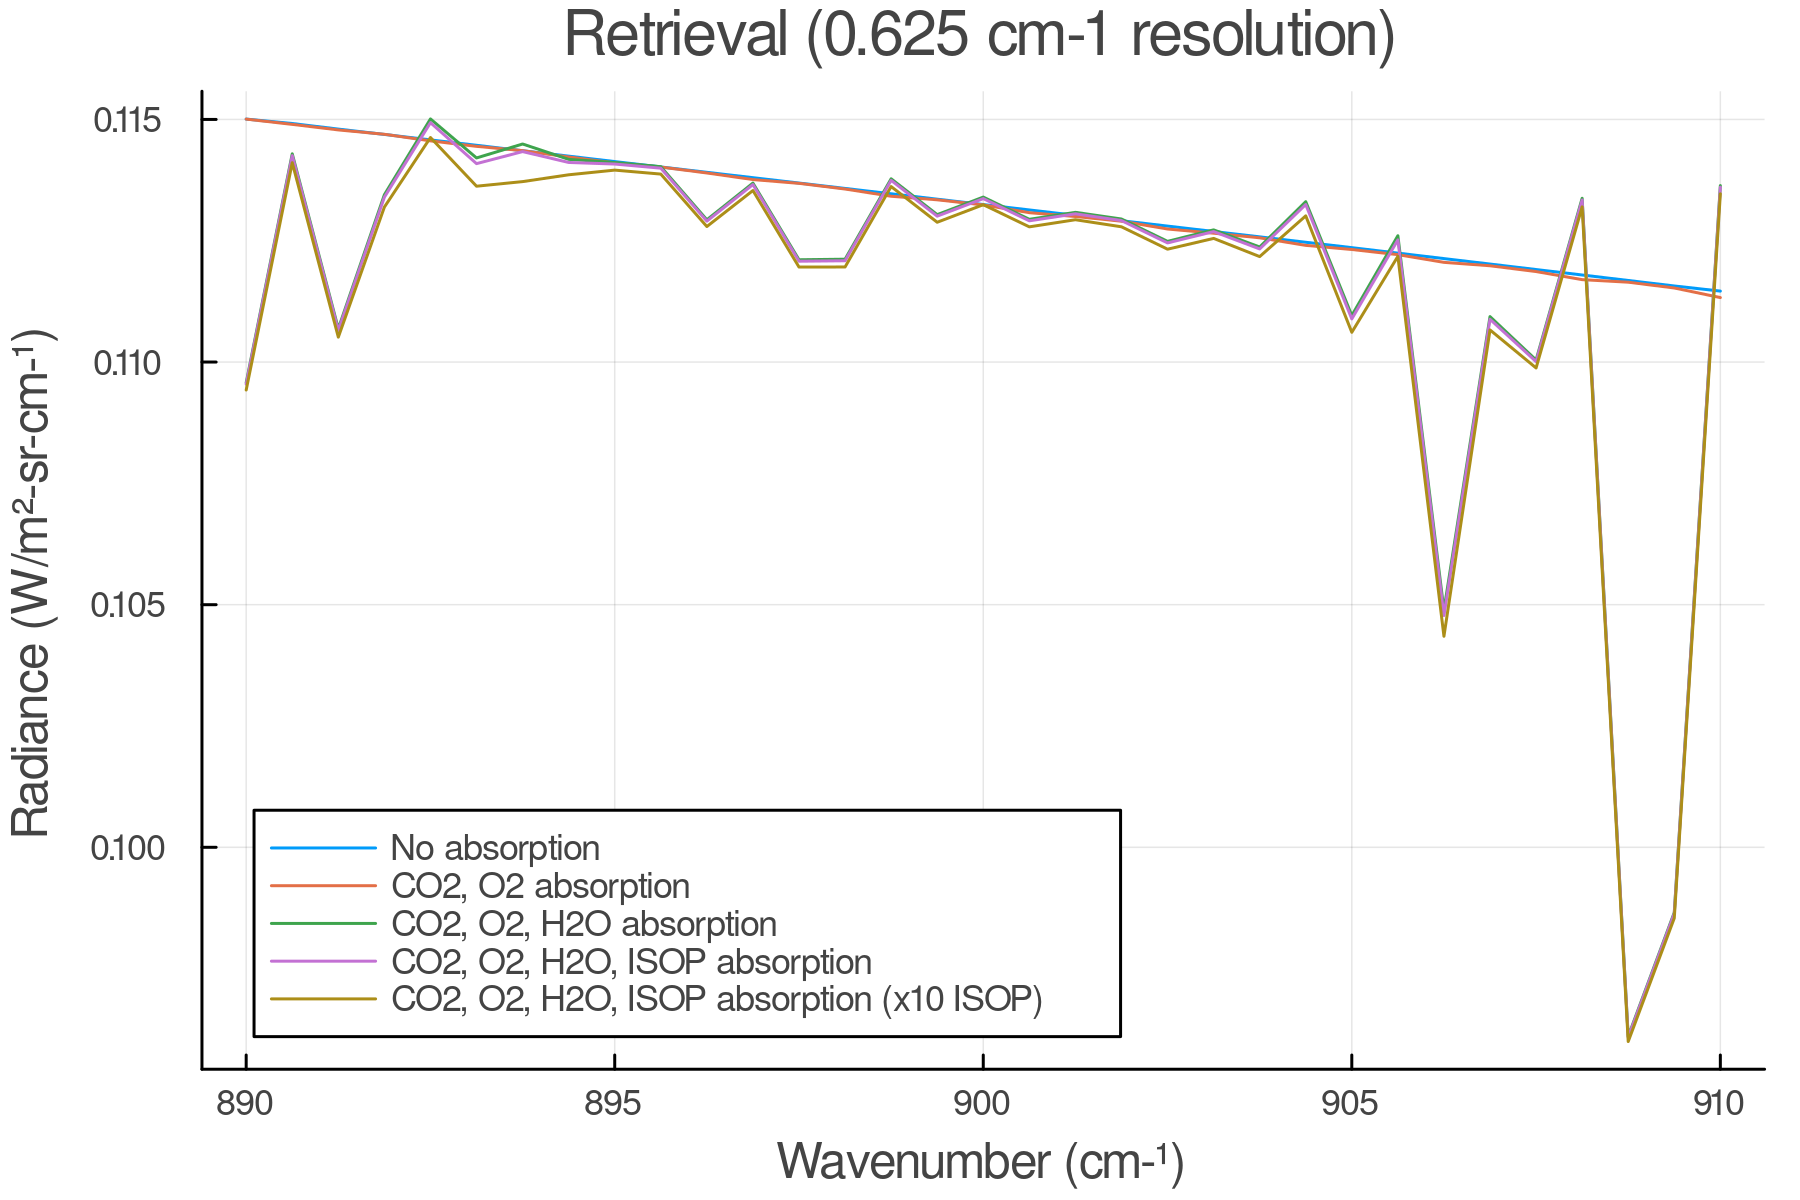

In [8]:
step_size = 0.625
nu = 890:step_size:910

p = plot(cris_instrument_kernel.ν_out, no_absorption_kernel, label = "No absorption", lw = 1, dpi = 300)
plot!(cris_instrument_kernel.ν_out, CO2_O2_absorption_kernel, label = "CO2, O2 absorption", lw = 1)
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label = "CO2, O2, H2O absorption", lw = 1)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel, label = "CO2, O2, H2O, ISOP absorption", lw = 1)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_kernel, label = "CO2, O2, H2O, ISOP absorption (x10 ISOP)", lw = 1)
xlabel!("Wavenumber (cm-¹)")
ylabel!("Radiance (W/m²-sr-cm-¹)")
title!("Retrieval ($(step_size) cm-1 resolution)")
# savefig(p, "Figures/sample_retrieval.png")

In [8]:
nu = 890:step_size:910

p1 = plot(cris_instrument_kernel.ν_out, CO2_O2_absorption_kernel -  no_absorption_kernel, label = "Contribution from CO2, O2", lw = 1, dpi = 300)
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel - CO2_O2_absorption_kernel, label = "Contribution from H2O", lw = 1)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel - CO2_O2_H2O_absorption_kernel, label = "Contribution from ISOP",)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_kernel - CO2_O2_H2O_absorption_kernel, label = "Contribution from ISOP x 10", lw = 2, color = "black")

xlabel!("Wavenumber (cm-¹)")
ylabel!("Radiance (W/m²-sr-cm-¹)")
title!("Retrieval ($(step_size) cm-1 resolution)")
# savefig(p1, "Figures/sample_retrieval_contributions.png")

UndefVarError: UndefVarError: `step_size` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Change vertical profile of isoprene

In [32]:
# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = 0;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_H2O_absorption[1][1,1,:]);

# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_profile_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile[1][1,1,:]);


# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = mean_vmr;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_constant = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_constant_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_constant[1][1,1,:]);

# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_x5_profile = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_x5_profile_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_x5_profile[1][1,1,:]);


# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = mean_vmr_x5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_x5_constant = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_x5_constant_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_x5_constant[1][1,1,:]);

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr 0 for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:50


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               68.1s /  90.9%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    57.6s   93.0%   14.4s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.09s    6.6%  18.9ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    2.94s    4.7%  13.8ms   9.55GiB   15.5%  45.9MiB
    interaction inv1 bla        213    814ms    1.3%  3.82ms   2.75GiB    4.5%  13.2MiB
    interaction inv2            213    795ms    1.3%  3.73ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [10]:
p = plot(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label = "No ISOP", lw = 1, color = "black",  dpi = 600)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_kernel, label = "ISOP profile, 1e16 molec cm-2", lw = 1.5, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_constant_kernel, label = "ISOP constant, 1e16 molec cm-2", lw = 1.5, color = "cornflowerblue", linestyle=:dash)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_profile_kernel, label = "ISOP profile, 5e16 molec cm-2", lw = 1.5, color = "firebrick")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_constant_kernel, label = "ISOP constant, 5e16 molec cm-2", color = "firebrick", lw = 1.5, linestyle=:dash)
ylabel!("Radiance (W/m²-sr-cm-¹)")
title!("Vertical Profile Sensitivity Runs")

p2 = plot(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_kernel - CO2_O2_H2O_absorption_kernel, color = "black", label = "Impact of 1e16 molec cm-2 (profile)", dpi = 300)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_constant_kernel - CO2_O2_ISOP_H2O_absorption_profile_kernel, label = "Impact of just changing profile, 1e16 molec cm-2", color = "cornflowerblue", linewidth = 2)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_profile_kernel - CO2_O2_H2O_absorption_kernel, color = "black", linestyle=:dash, label = "Impact of 5e16 molec cm-2 (profile)")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_constant_kernel - CO2_O2_ISOP_H2O_absorption_x5_profile_kernel, label = "Impact of just changing profile, 5e16 molec cm-2", color = "firebrick", linewidth = 2)
title!("Contribution of ISOP vertical profile")

p3 = plot(p, p2, size = (900, 600))
xlabel!("Wavenumber (cm-¹)")
# savefig(p3, "Figures/vertical_profile_sensitivity.png")

UndefVarError: UndefVarError: `CO2_O2_ISOP_H2O_absorption_profile_kernel` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Impact of water

In [25]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity ./ 2;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02 / 2; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_half_water = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_half_water_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_half_water[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 2;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02 * 2; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_double_water = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_double_water_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_double_water[1][1,1,:]);

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:06


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr [1.4030530337549863e-12, 1.711165396045544e-12, 1.8979955029863046e-12, 2.0519391910056583e-12, 2.083041636069538e-12, 2.1113983166287653e-12, 2.1232958715700076e-12, 2.1323176042642443e-12, 2.1326179648895046e-12, 2.1336613826861138e-12, 2.1292639758030418e-12, 2.108552507706918e-12, 2.080265403492376e-12, 2.0373288407427026e-12, 1.9899059680028582e-12, 1.9327096651977627e-12, 1.884506218630122e-12, 1.8456980797054712e-12, 1.797914592316374e-12, 1.7476361335866386e-12, 1.6859436300364906e-12, 1.6254640513579942e-12, 1.550242359371623e-12, 1.4844666793578653e-12, 1.4295778782980049e-12, 1.3894941730541175e-12, 1.3609560483018867e-12, 1.350213892692409e-12, 1.3419920605883818e-12, 1.325305106547603e-12, 1.2907921700389124e-12, 1.2448508641682565e-12, 1.1840575

Progress: 100%|█████████████████████████████████████████| Time: 0:00:48


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               66.5s /  91.4%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    56.5s   92.9%   14.1s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.08s    6.7%  18.9ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    2.92s    4.8%  13.7ms   9.55GiB   15.5%  45.9MiB
    interaction inv2            213    860ms    1.4%  4.04ms   2.75GiB    4.5%  13.2MiB
    interaction inv1 bla        213    787ms    1.3%  3.70ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


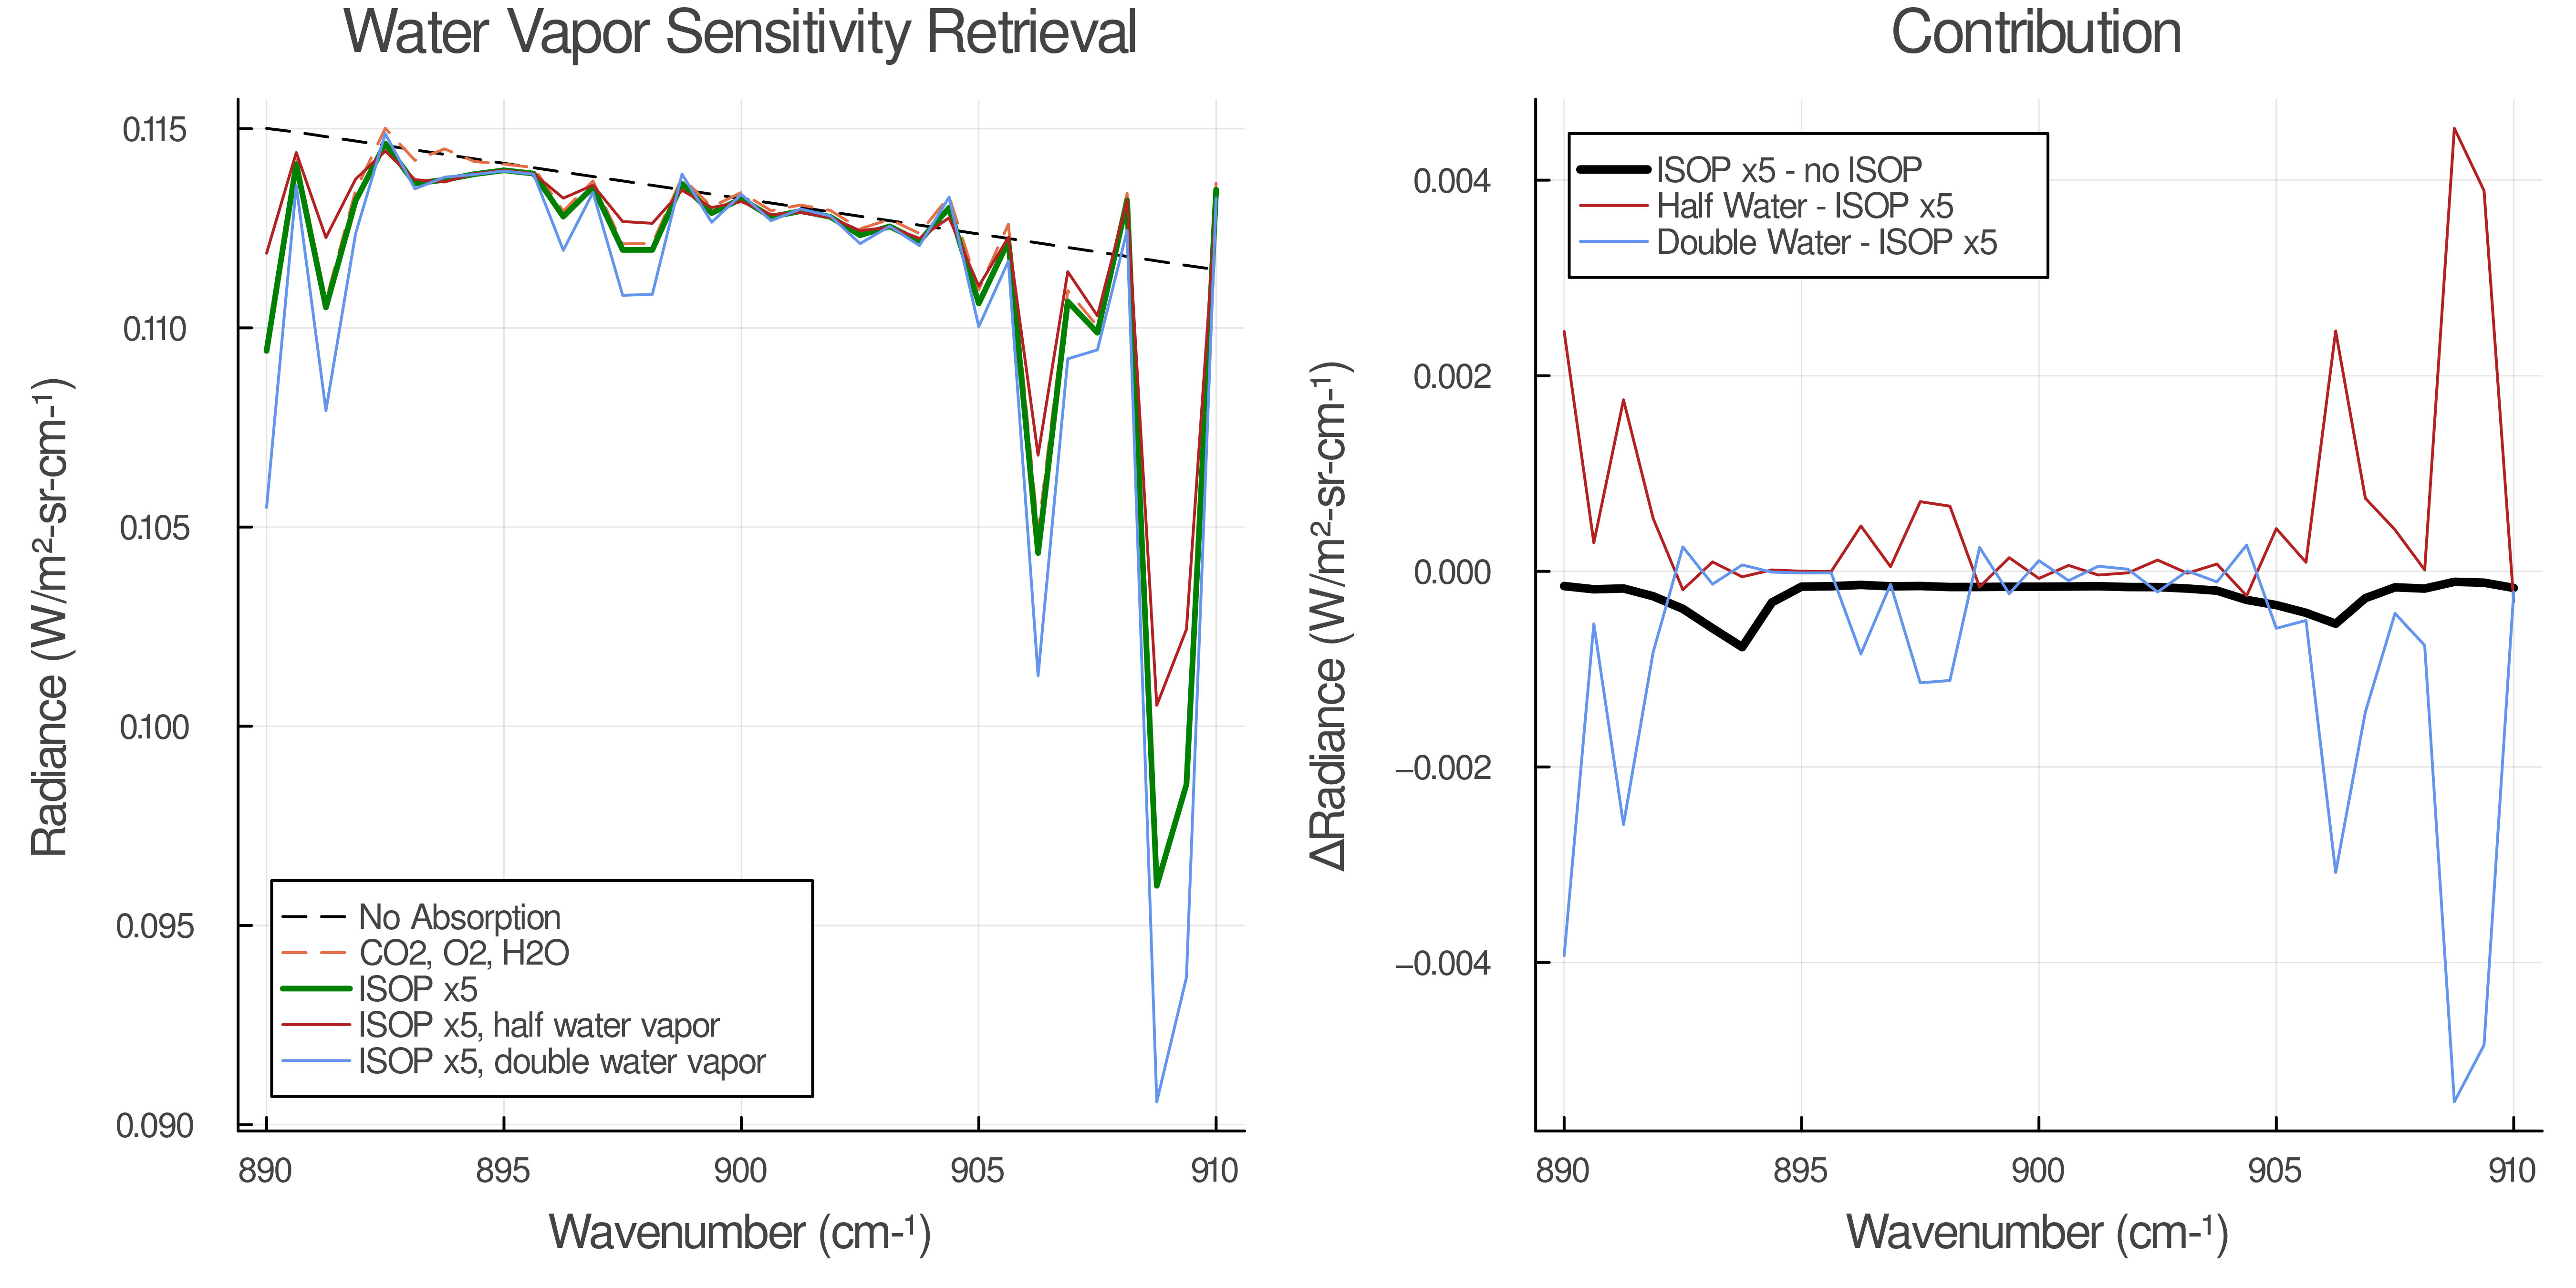

In [30]:
step_size = 0.625
nu = 890:step_size:910

p1 = plot(cris_instrument_kernel.ν_out, no_absorption_kernel, label = "No Absorption", lw = 1, dpi = 600, linestyle=:dash, color = "black")# xlimit = [892, 895], ylimit = [0.112, 0.115])
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label = "CO2, O2, H2O", lw = 1, dpi = 300, linestyle=:dash)# xlimit = [892, 895], ylimit = [0.112, 0.115])
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel, label = "ISOP x5", lw = 2, color = "green", dpi = 600)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_half_water_kernel, label = "ISOP x5, half water vapor", lw = 1, color = "firebrick")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_double_water_kernel, label = "ISOP x5, double water vapor", lw = 1, color = "cornflowerblue")

xlabel!("Wavenumber (cm-¹)")
ylabel!("Radiance (W/m²-sr-cm-¹)")
title!("Water Vapor Sensitivity Retrieval")

p2 = plot(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel - CO2_O2_H2O_absorption_kernel, label = "ISOP x5 - no ISOP", lw = 3, dpi = 600, color = "black")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_half_water_kernel - CO2_O2_ISOP_H2O_absorption_kernel, label = "Half Water - ISOP x5", lw = 1, dpi = 300, color = "firebrick")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_double_water_kernel - CO2_O2_ISOP_H2O_absorption_kernel, label = "Double Water - ISOP x5", lw = 1, dpi = 300, color = "cornflowerblue")
title!("Contribution")
ylabel!("ΔRadiance (W/m²-sr-cm-¹)")

p3 = plot(p1, p2, size = (900, 450), left_margin=5Plots.mm, bottom_margin = 5Plots.mm, top_margin = 3Plots.mm)
xlabel!("Wavenumber (cm-¹)")
# savefig(p3, "Figures/water_vapor_retrieval.png")

## Impact of nitric acid

In [83]:
# parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
# parameters.T = temperatures;
# parameters.p = pressures;
# parameters.q = specific_humidity;
# parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
# parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

# model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
# CO2_O2_ISOP_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
# CO2_O2_ISOP_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910-NITRIC-ACID.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;
parameters.absorption_params.vmr["HNO3"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile_hno3 = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_profile_hno3_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile_hno3[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910-NITRIC-ACID.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;
parameters.absorption_params.vmr["HNO3"] = specific_humidity ./ 1000 * 1e-7 * 2;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile_hno3_x2 = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_profile_hno3_x2_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile_hno3_x2[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910-NITRIC-ACID.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;
parameters.absorption_params.vmr["HNO3"] = 1e-9;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile_hno3_1ppb = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_profile_hno3_constant_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile_hno3_1ppb[1][1,1,:]);


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:06


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr [1.4030530337549863e-12, 1.711165396045544e-12, 1.8979955029863046e-12, 2.0519391910056583e-12, 2.083041636069538e-12, 2.1113983166287653e-12, 2.1232958715700076e-12, 2.1323176042642443e-12, 2.1326179648895046e-12, 2.1336613826861138e-12, 2.1292639758030418e-12, 2.108552507706918e-12, 2.080265403492376e-12, 2.0373288407427026e-12, 1.9899059680028582e-12, 1.9327096651977627e-12, 1.884506218630122e-12, 1.8456980797054712e-12, 1.797914592316374e-12, 1.7476361335866386e-12, 1.6859436300364906e-12, 1.6254640513579942e-12, 1.550242359371623e-12, 1.4844666793578653e-12, 1.4295778782980049e-12, 1.3894941730541175e-12, 1.3609560483018867e-12, 1.350213892692409e-12, 1.3419920605883818e-12, 1.325305106547603e-12, 1.2907921700389124e-12, 1.2448508641682565e-12, 1.1840575

Progress: 100%|█████████████████████████████████████████| Time: 0:00:48


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:                426s /  97.1%            509GiB /  99.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  5     409s   98.9%   81.8s    493GiB   97.7%  98.6GiB
RT Kernel                       216    4.27s    1.0%  19.8ms   9.66GiB    1.9%  45.8MiB
  interaction                   213    3.07s    0.7%  14.4ms   9.55GiB    1.9%  45.9MiB
    interaction inv1 bla        213    895ms    0.2%  4.20ms   2.75GiB    0.5%  13.2MiB
    interaction inv2            213    812ms    0.2%  3.81ms   2.75GiB    0.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [99]:
step_size = 0.625
nu = 890:step_size:910

p1 = plot(cris_instrument_kernel.ν_out, no_absorption_kernel, label = "No Absorption", lw = 1, dpi = 600, linestyle=:dash, color = "black")
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label = "CO2, O2, H2O", lw = 1, dpi = 300, linestyle=:dash, xlimit = [892, 895], ylimit = [0.112, 0.115])
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_hno3_kernel, label = "HNO3 (vertical profile)", lw = 2, color = "cornflowerblue", dpi = 600)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_hno3_x2_kernel, label = "HNO3 x 2 (vertical profile)", lw = 1, linestyle=:dash, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_hno3_constant_kernel, label = "HNO3, 1 ppbv", lw = 1, color = "firebrick")

xlabel!("Wavenumber (cm-¹)")
ylabel!("Radiance (W/m²-sr-cm-¹)")
title!("HNO3 Sensitivity Retrieval")

p2 = plot(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel - CO2_O2_H2O_absorption_kernel, label = "ISOP x5 - no ISOP", lw = 3, dpi = 600, color = "black")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_hno3_kernel - CO2_O2_ISOP_H2O_absorption_kernel, label = "HNO3 (vertical profile) - ISOP x5", lw = 1, dpi = 300, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_hno3_x2_kernel - CO2_O2_ISOP_H2O_absorption_kernel, label = "HNO3 x2 (vertical profile) - ISOP x5", lw = 1, dpi = 300, linestyle=:dash, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_hno3_constant_kernel - CO2_O2_ISOP_H2O_absorption_kernel, label = "HNO3, 1 ppbv (constant) - ISOP x5", lw = 1, dpi = 300, color = "firebrick")

title!("Contribution")
ylabel!("ΔRadiance (W/m²-sr-cm-¹)")

p3 = plot(p1, p2, size = (900, 450), left_margin=5Plots.mm, bottom_margin = 5Plots.mm, top_margin = 3Plots.mm)
xlabel!("Wavenumber (cm-¹)")
savefig(p3, "Figures/hno3_retrieval.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/Figures/hno3_retrieval.png"

## Impact of aerosols

In [4]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
# parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
# parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption[3][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910_aerosols.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
# parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
# parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_aerosols = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_aerosols_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_aerosols[3][1,1,:]);

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

Progress: 100%|█████████████████████████████████████████| Time: 0:00:08


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
FT_dual = Float64
Finished initializing arrays
Fourier Moment: 0/2


┌ Info: Processing on: CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (14, 14, 2001)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/rt_run.jl:108
Looping over layers ... 100%|████████████████████████████| Time: 0:00:04


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:08


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:08


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               37.9s /  88.3%           82.8GiB /  98.0%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
RT Kernel                       216    24.9s   74.3%   115ms   68.7GiB   84.7%   326MiB
  doubling                      216    19.1s   57.1%  88.6ms   54.9GiB   67.6%   260MiB
    Batch Inv Doubling        1.43k    8.55s   25.5%  6.00ms   24.2GiB   29.9%  17.4MiB
  interaction                   213    4.14s   12.4%  19.4ms   13.7GiB   16.9%  66.0MiB
    interaction inv2            213    1.12s    3.3%  5.26ms   3.62GiB    4.5%  17.4MiB
    interaction inv1 bla       

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


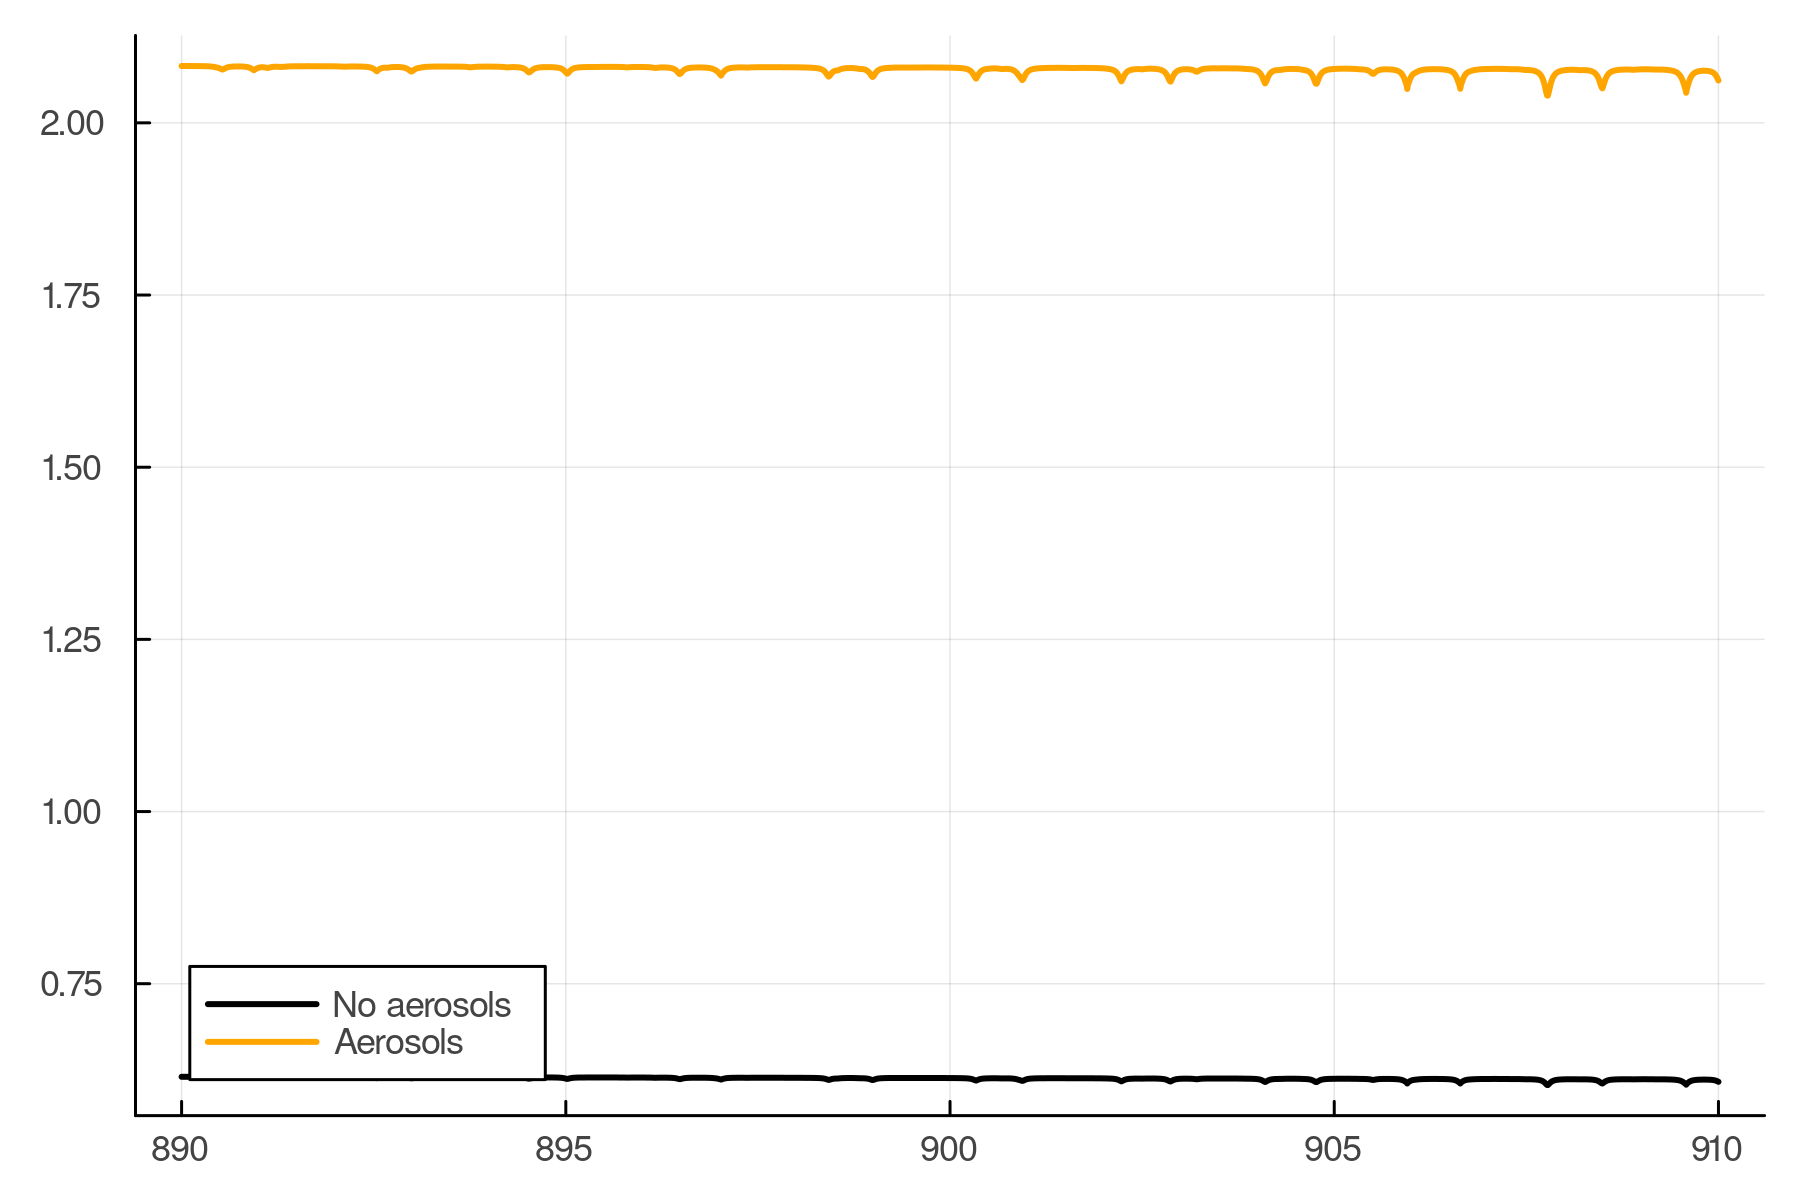

In [13]:
index = 1

p = plot(890:0.01:910, CO2_O2_ISOP_H2O_absorption[1][index,1,:] + CO2_O2_ISOP_H2O_absorption[2][index,1,:], label = "No aerosols", lw = 2, dpi = 300, color = "black")
plot!(890:0.01:910, CO2_O2_ISOP_H2O_absorption_aerosols[1][index,1,:] + CO2_O2_ISOP_H2O_absorption_aerosols[2][index,1,:], label = "Aerosols", lw = 2, dpi = 300, color = "orange")


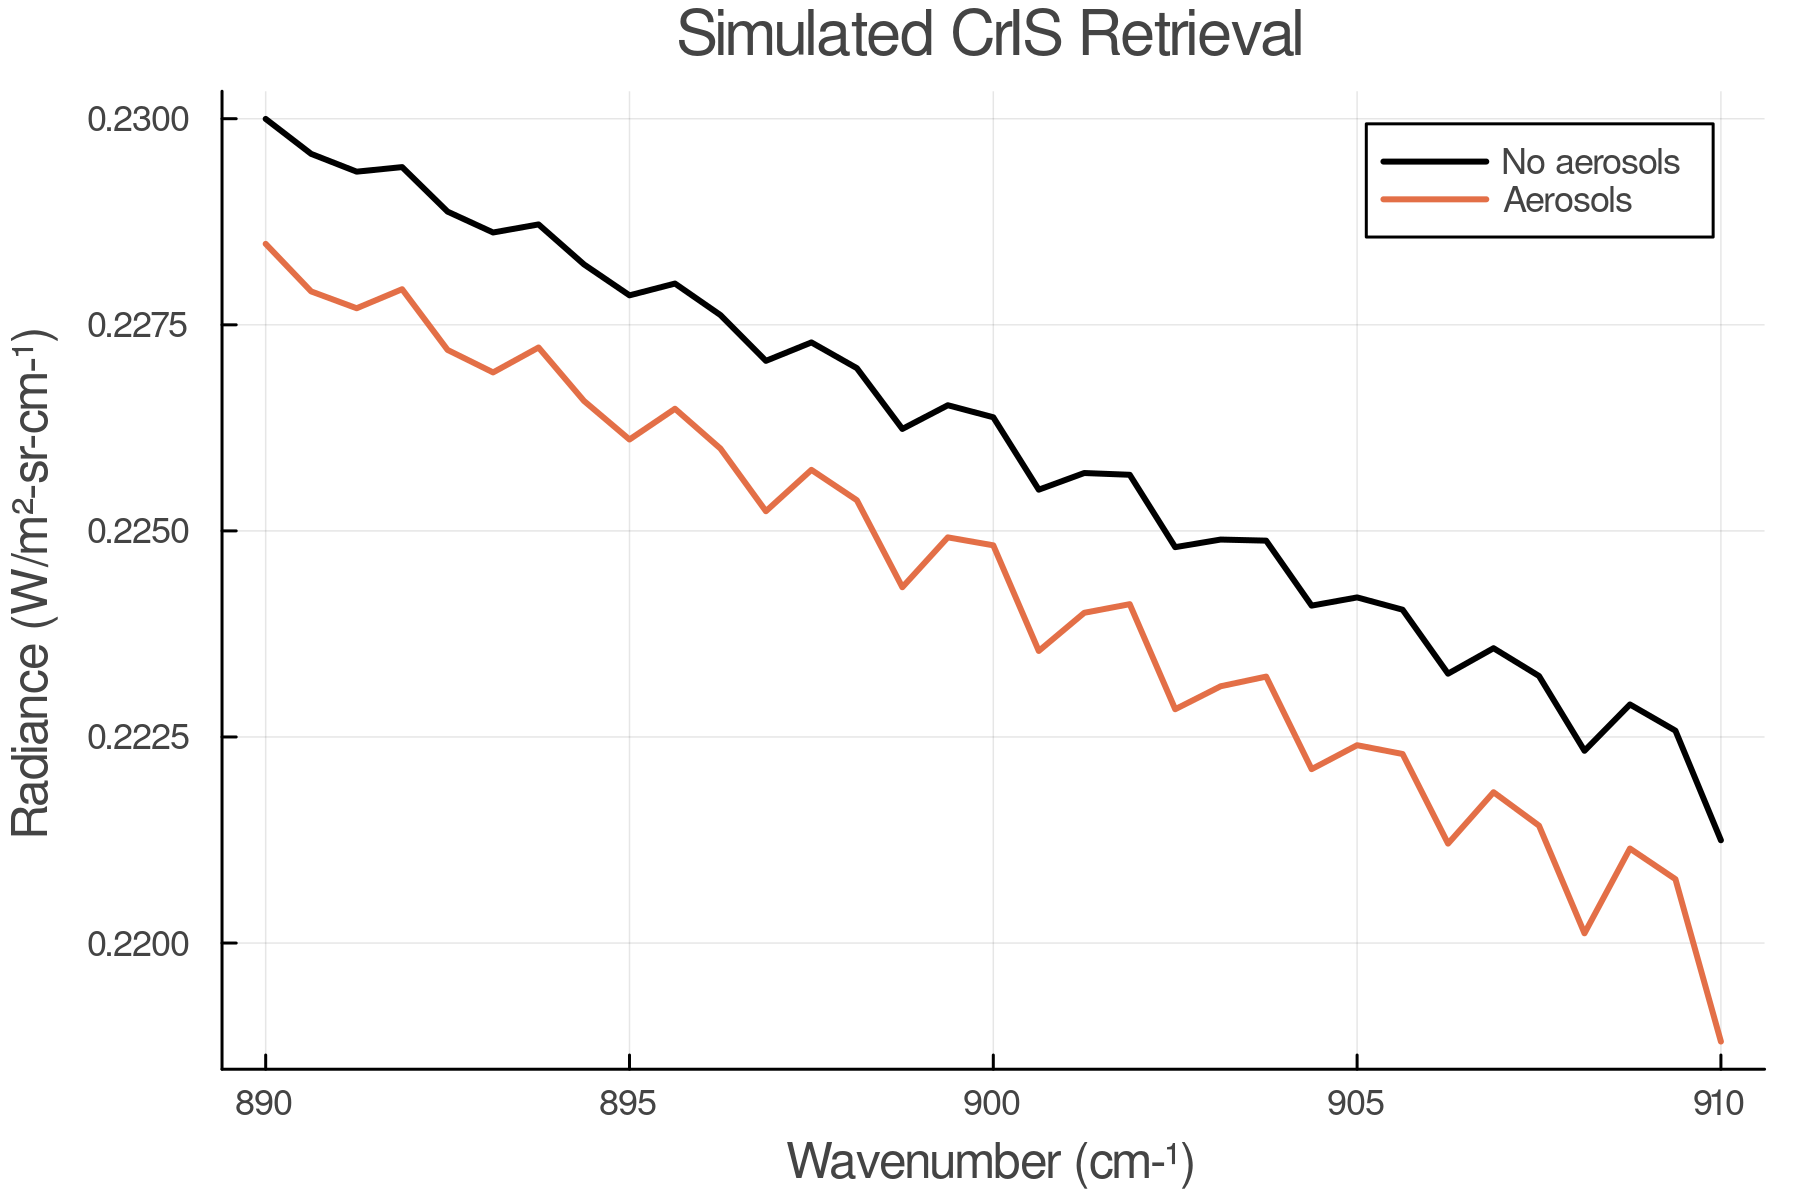

In [35]:
step_size = 0.625
nu = 890:step_size:910

CO2_O2_ISOP_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption[1][4,1,:]);
CO2_O2_ISOP_H2O_absorption_aerosols_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_aerosols[1][4,1,:]);

p = plot(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel, label = "No aerosols", lw = 2, dpi = 300, color = "black")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_aerosols_kernel, label = "Aerosols", lw = 2)

xlabel!("Wavenumber (cm-¹)")
ylabel!("Radiance (W/m²-sr-cm-¹)")
title!("Simulated CrIS Retrieval")
# savefig(p, "Figures/sample_retrieval.png")

In [25]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/aerosol_check.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
# parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
# parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
aerosols = vSmartMOM.CoreRT.rt_run(model); # Run the model
# CO2_O2_ISOP_H2O_absorption_aerosols_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_aerosols[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/no_aerosol_check.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
# parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
# parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
no_aerosols = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(nquad_radius, λ) = (2500, 11.145510835913313)
("Mie", FT, FT2) = ("Mie", Float64, Float64)
aerosol_optics_raw.k = 13.660162758467537
((aerosol_optics[i_band])[i_aer]).k = 13.660162758467537
FT_dual = Float64
Finished initializing arrays
Fourier Moment: 0/2


┌ Info: AOD at band 1 : 0.43133532968173754, truncation factor = 0.0005142407220133371
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/model_from_parameters.jl:178
┌ Info: Processing on: CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (16, 16, 1001)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/rt_run.jl:108


AssertionError: AssertionError: all μ's within compute_Z_moments have to be ∈ ]0,1]

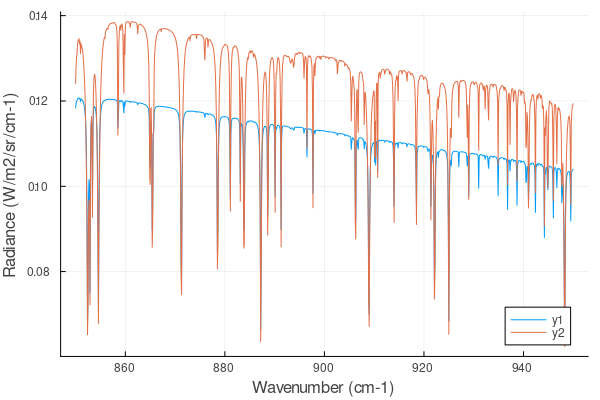

In [ ]:
nu = 850:0.1:950

plot(nu, no_aerosols[1][1,1,:], l)
plot!(nu, aerosols[1][1,1,:])
ylabel!("Radiance (W/m2/sr/cm-1)")
xlabel!("Wavenumber (cm-1)")


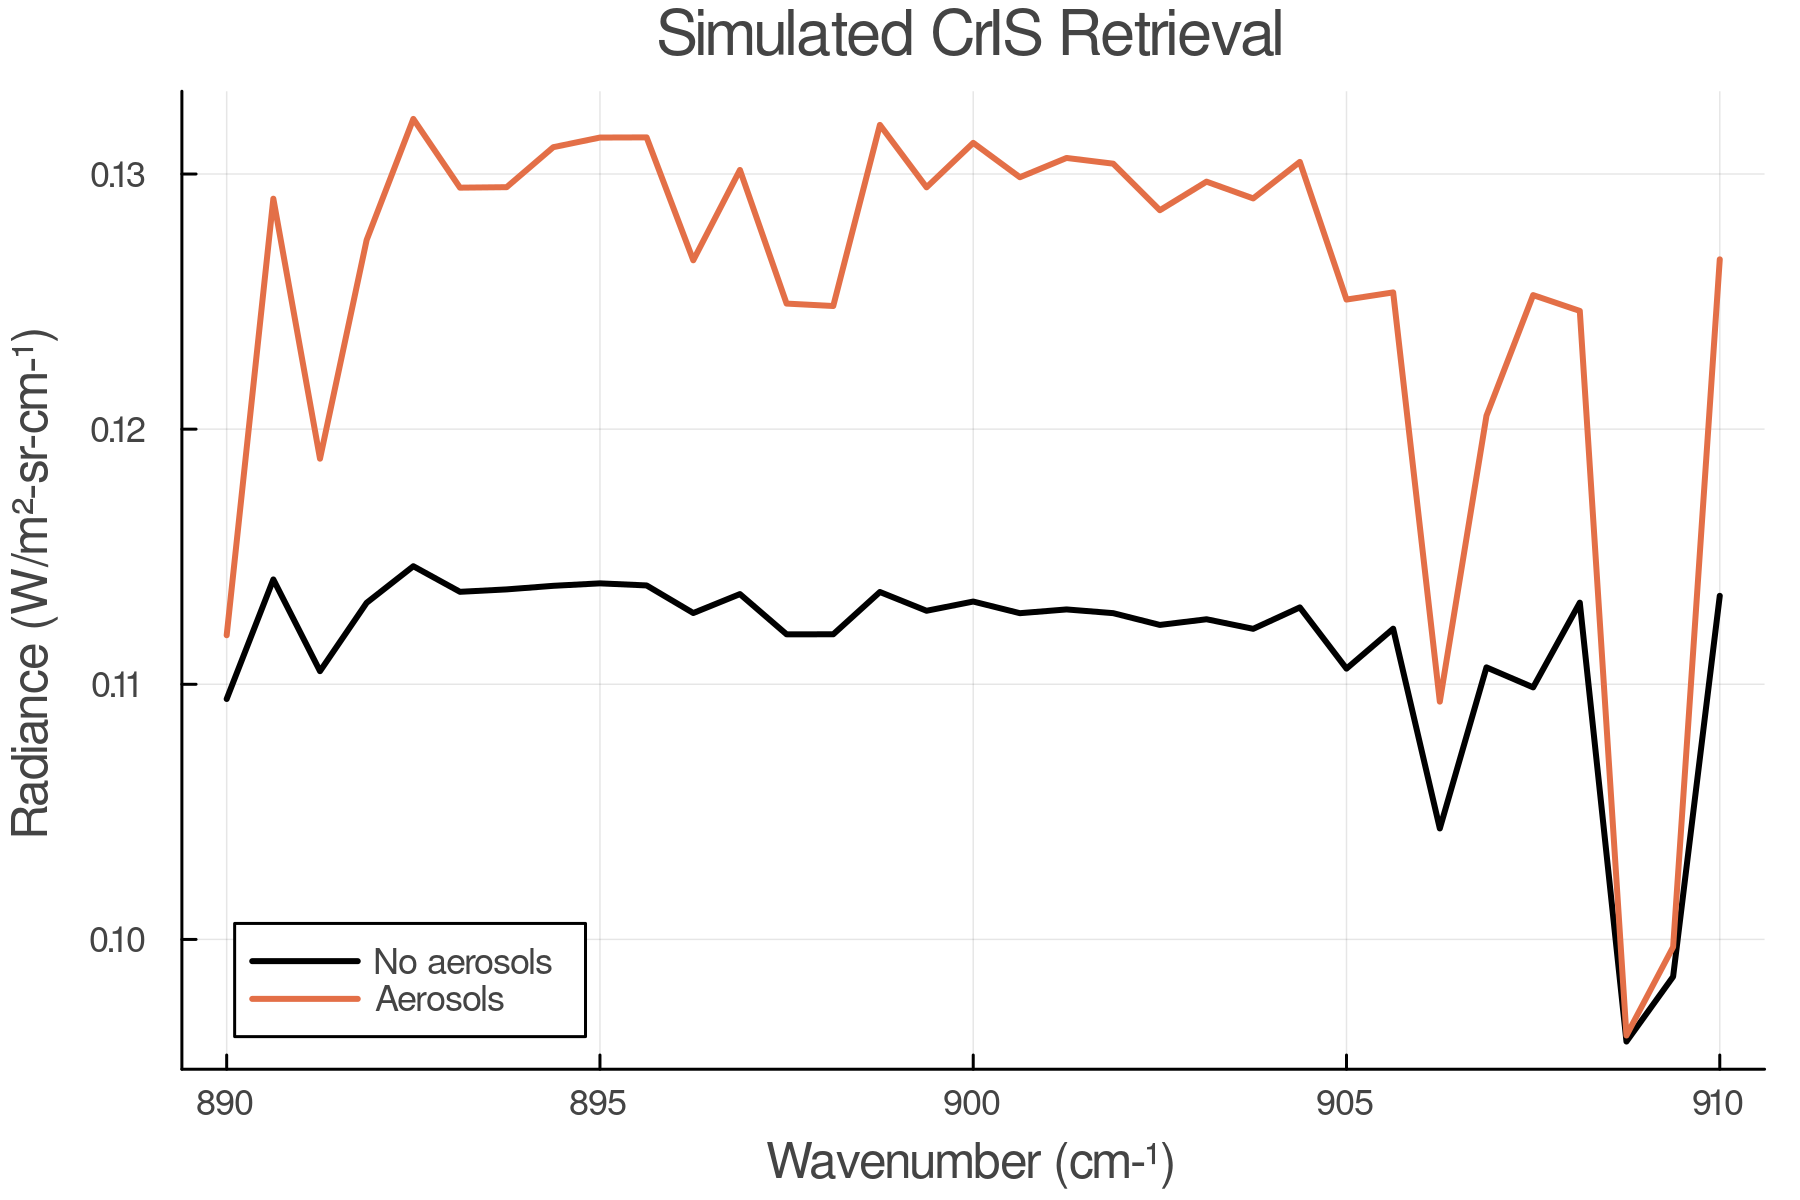

In [467]:
step_size = 0.625
nu = 890:step_size:910

p = plot(FTS_instr.ν_out, CO2_O2_ISOP_H2O_absorption_kernel, label = "No aerosols", lw = 2, dpi = 300, color = "black")
plot!(FTS_instr.ν_out, CO2_O2_ISOP_H2O_absorption_aerosols_kernel, label = "Aerosols", lw = 2)

xlabel!("Wavenumber (cm-¹)")
ylabel!("Radiance (W/m²-sr-cm-¹)")
title!("Simulated CrIS Retrieval")
# savefig(p, "Figures/sample_retrieval.png")

# Instrument Operator

In [13]:
# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910-INSTRUMENT-OPERATOR.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
instrument_operator_output = vSmartMOM.CoreRT.rt_run(model); # Run the model

# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_check_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
precoarsened_output = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
read_hitran_isopreneComputing profile for ISOP with vmr [2.8061060675099726e-13, 3.422330792091088e-13, 3.7959910059726096e-13, 4.1038783820113164e-13, 4.166083272139076e-13, 4.2227966332575304e-13, 4.2465917431400157e-13, 4.2646352085284886e-13, 4.2652359297790095e-13, 4.2673227653722277e-13, 4.2585279516060835e-13, 4.2171050154138353e-13, 4.1605308069847525e-13, 4.074657681485405e-13, 3.979811936005717e-13, 3.8654193303955254e-13, 3.769012437260244e-13, 3.6913961594109423e-13, 3.595829184632748e-13, 3.495272267173277e-13, 3.371887260072981e-13, 3.2509281027159884e-13, 3.100484718743246e-13, 2.9689333587157306e-13, 2.85915575659601e-13, 2.778988346108235e-13, 2.7219120966037733e-13, 2.700427785384818e-13, 2.6839841211767634e-13, 2.650610213095206e-13, 2.581584340077825e-13, 2.489701728336513e-13, 2.36811501963529

Progress: 100%|█████████████████████████████████████████| Time: 0:00:47


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               67.3s /  91.7%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    57.3s   92.8%   14.3s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.19s    6.8%  19.4ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    2.99s    4.8%  14.0ms   9.55GiB   15.5%  45.9MiB
    interaction inv1 bla        213    844ms    1.4%  3.96ms   2.75GiB    4.5%  13.2MiB
    interaction inv2            213    827ms    1.3%  3.88ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [14]:
T_conv = conv_spectra(cris_instrument_kernel, ν, instrument_operator_output[1][1,1,:]);
plot(FTS_instr.ν_out, T_conv, label="Convolved", lw = 2)

# plot!(ν_min:sampling:ν_max, precoarsened_output[1][1,1,:], label="Pre-coarsened", lw = 0.6)
# plot!(ν, instrument_operator_output[1][1,1,:], label="Convolved")

UndefVarError: UndefVarError: `FTS_instr` not defined in `Main`
Suggestion: check for spelling errors or missing imports.